<a href="https://colab.research.google.com/github/heekyeongkim/todo/blob/main/%EC%A0%84%EB%AC%B8%EA%B0%80_%EB%B6%84%EC%84%9D_%EA%B3%BC%EC%A0%95_%EC%8B%9C%ED%97%98%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 파일을 불러오고 데이터프레임으로 저장합니다.
# 'your_file_name.csv'를 실제 파일 이름으로 변경해주세요.
df = pd.read_csv('1775638931283_18e0238a.csv')

# 데이터프레임의 상위 5행을 출력하여 확인합니다.
display(df.head())

,민원ID,접수일자,분야,처리부서,처리기간(일),처리상태,만족도,재접수여부,접수채널,연령대
0,M2025-0001,2025-01-01,복지,복지과,7,완료,1,N,온라인,40대
1,M2025-0002,2025-01-01,일반행정,민원봉사과,5,완료,2,N,전화,50대
2,M2025-0003,2025-01-01,교육,교육과,6,완료,4,N,온라인,50대
3,M2025-0004,2025-01-01,건설,건설과,4,진행중,3,N,온라인,50대
4,M2025-0005,2025-01-01,환경,환경과,16,완료,3,N,온라인,20대


In [ ]:
# 전체 민원의 평균 처리기간 계산
overall_avg_processing_time = df['처리기간(일)'].mean()

# '환경' 분야 민원 필터링
environment_complaints_df = df[df['분야'] == '환경']

# '환경' 분야 민원의 평균 처리기간 계산
environment_avg_processing_time = environment_complaints_df['처리기간(일)'].mean()

# 비교
difference = environment_avg_processing_time - overall_avg_processing_time
is_longer_than_3_days = difference >= 3

print(f"전체 민원의 평균 처리기간: {overall_avg_processing_time:.2f}일")
print(f"환경 분야 민원의 평균 처리기간: {environment_avg_processing_time:.2f}일")
print(f"환경 분야 민원의 평균 처리기간은 전체 평균보다 {difference:.2f}일 더 깁니다.")

if is_longer_than_3_days:
    print("결론: 환경 분야 민원의 평균 처리기간은 전체 평균보다 3일 이상 깁니다.")
else:
    print("결론: 환경 분야 민원의 평균 처리기간은 전체 평균보다 3일 이상 길지 않습니다.")

전체 민원의 평균 처리기간: 6.75일
환경 분야 민원의 평균 처리기간: 11.57일
환경 분야 민원의 평균 처리기간은 전체 평균보다 4.82일 더 깁니다.
결론: 환경 분야 민원의 평균 처리기간은 전체 평균보다 3일 이상 깁니다.


In [ ]:
# 각 부서별 재접수율 계산
# '재접수여부' 컬럼에서 'Y'인 경우를 1로, 'N'인 경우를 0으로 변환하여 평균을 구하면 재접수율이 됩니다.
df['재접수여부_수치'] = df['재접수여부'].apply(lambda x: 1 if x == 'Y' else 0)
re_submission_rates = df.groupby('처리부서')['재접수여부_수치'].mean().sort_values(ascending=False)

# 재접수율이 가장 높은 부서 확인
highest_re_submission_dept = re_submission_rates.index[0]
highest_re_submission_rate = re_submission_rates.iloc[0]

# 전체 부서 평균 재접수율 계산
overall_avg_re_submission_rate = df['재접수여부_수치'].mean()

# '건설과'의 재접수율 확인
construction_dept_rate = re_submission_rates.get('건설과', 0) # '건설과'가 없으면 0으로 처리

print(f"각 부서별 재접수율:\n{re_submission_rates.apply(lambda x: f'{x:.2%}')}")
print(f"\n재접수율이 가장 높은 부서: {highest_re_submission_dept} ({highest_re_submission_rate:.2%})")
print(f"전체 부서 평균 재접수율: {overall_avg_re_submission_rate:.2%}")
print(f"'건설과'의 재접수율: {construction_dept_rate:.2%}")

# 조건 확인
is_construction_highest = (highest_re_submission_dept == '건설과')
is_more_than_double_avg = (construction_dept_rate > 2 * overall_avg_re_submission_rate)

print("\n--- 확인 결과 ---")
if is_construction_highest:
    print(f"'건설과'는 재접수율이 가장 높은 부서입니다 ({highest_re_submission_rate:.2%}).")
else:
    print(f"'건설과'는 재접수율이 가장 높은 부서가 아닙니다. 가장 높은 부서는 {highest_re_submission_dept}입니다.")

if is_more_than_double_avg:
    print(f"'건설과'의 재접수율은 전체 부서 평균의 2배를 초과합니다. ({construction_dept_rate:.2%} > 2 * {overall_avg_re_submission_rate:.2%})")
else:
    print(f"'건설과'의 재접수율은 전체 부서 평균의 2배를 초과하지 않습니다. ({construction_dept_rate:.2%} <= 2 * {overall_avg_re_submission_rate:.2%})")

각 부서별 재접수율:
처리부서
건설과      33.45%
환경과      19.50%
복지과      10.89%
교통과       9.27%
민원봉사과     5.76%
교육과       4.26%
Name: 재접수여부_수치, dtype: object

재접수율이 가장 높은 부서: 건설과 (33.45%)
전체 부서 평균 재접수율: 15.13%
'건설과'의 재접수율: 33.45%

--- 확인 결과 ---
'건설과'는 재접수율이 가장 높은 부서입니다 (33.45%).
'건설과'의 재접수율은 전체 부서 평균의 2배를 초과합니다. (33.45% > 2 * 15.13%)


In [ ]:
# 만족도 하위 20% (1점 또는 2점) 민원 필터링
low_satisfaction_df = df[df['만족도'].isin([1, 2])]

# '환경', '건설', '교통' 분야에 해당하는 민원 필터링
target_fields = ['환경', '건설', '교통']
concentrated_complaints_df = low_satisfaction_df[low_satisfaction_df['분야'].isin(target_fields)]

# 총 만족도 하위 민원 수 계산
total_low_satisfaction_count = len(low_satisfaction_df)

# 특정 3개 분야에 집중된 만족도 하위 민원 수 계산
concentrated_count = len(concentrated_complaints_df)

# 비율 계산
if total_low_satisfaction_count > 0:
    concentration_percentage = (concentrated_count / total_low_satisfaction_count) * 100
else:
    concentration_percentage = 0

# 조건 확인
is_concentrated_over_70_percent = (concentration_percentage >= 70)

print(f"총 만족도 하위(1-2점) 민원 수: {total_low_satisfaction_count}건")
print(f"환경, 건설, 교통 분야에 집중된 만족도 하위 민원 수: {concentrated_count}건")
print(f"해당 3개 분야 집중도: {concentration_percentage:.2f}%")

print("\n--- 확인 결과 ---")
if is_concentrated_over_70_percent:
    print("결론: 만족도 하위 민원의 70% 이상이 환경, 건설, 교통 3개 분야에 집중되어 있습니다.")
else:
    print("결론: 만족도 하위 민원의 70% 이상이 환경, 건설, 교통 3개 분야에 집중되어 있지 않습니다.")

총 만족도 하위(1-2점) 민원 수: 450건
환경, 건설, 교통 분야에 집중된 만족도 하위 민원 수: 291건
해당 3개 분야 집중도: 64.67%

--- 확인 결과 ---
결론: 만족도 하위 민원의 70% 이상이 환경, 건설, 교통 3개 분야에 집중되어 있지 않습니다.


월별 접수 건수와 평균 처리기간 사이의 상관관계 (Pearson r): -0.22
결론: 월별 접수 건수와 평균 처리기간 사이에 양의 상관관계(r > 0.5)가 존재하지 않거나, 약한 상관관계입니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

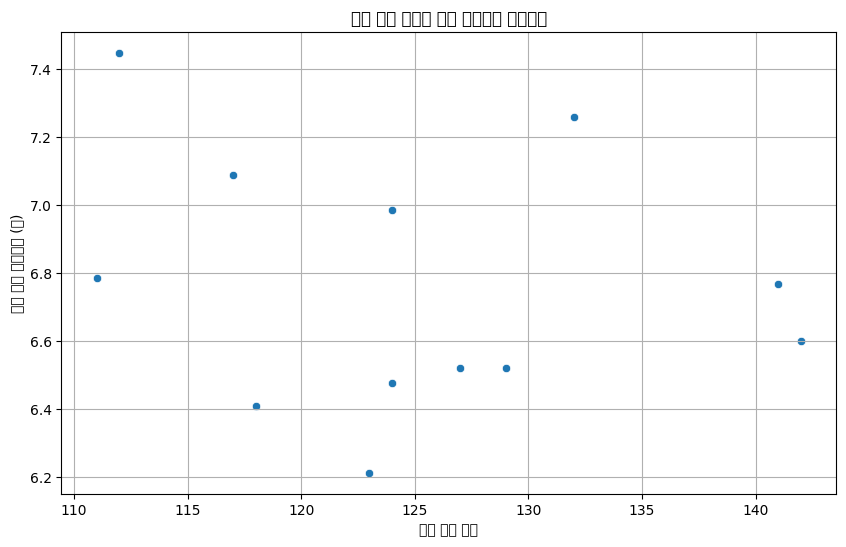

In [ ]:
import pandas as pd

# '접수일자' 컬럼을 datetime 형식으로 변환
df['접수일자'] = pd.to_datetime(df['접수일자'])

# 월별 접수 건수 계산
monthly_receipt_counts = df.groupby(df['접수일자'].dt.to_period('M')).size().reset_index(name='접수건수')
monthly_receipt_counts['접수일자'] = monthly_receipt_counts['접수일자'].dt.to_timestamp()

# 월별 평균 처리기간 계산
monthly_avg_processing_time = df.groupby(df['접수일자'].dt.to_period('M'))['처리기간(일)'].mean().reset_index(name='평균처리기간')
monthly_avg_processing_time['접수일자'] = monthly_avg_processing_time['접수일자'].dt.to_timestamp()

# 두 데이터프레임 병합
merged_df = pd.merge(monthly_receipt_counts, monthly_avg_processing_time, on='접수일자')

# 상관관계 계산
correlation = merged_df['접수건수'].corr(merged_df['평균처리기간'])

print(f"월별 접수 건수와 평균 처리기간 사이의 상관관계 (Pearson r): {correlation:.2f}")

# 조건 확인
if correlation > 0.5:
    print("결론: 월별 접수 건수와 평균 처리기간 사이에 양의 상관관계(r > 0.5)가 존재합니다.")
else:
    print("결론: 월별 접수 건수와 평균 처리기간 사이에 양의 상관관계(r > 0.5)가 존재하지 않거나, 약한 상관관계입니다.")

# 시각화를 통해 상관관계 확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='접수건수', y='평균처리기간', data=merged_df)
plt.title('월별 접수 건수와 평균 처리기간 상관관계')
plt.xlabel('월별 접수 건수')
plt.ylabel('월별 평균 처리기간 (일)')
plt.grid(True)
plt.show()